In [2]:
import torch
# torchvision.datasets.FashionMNIST
import torchvision
# 修改数据集格式
from torchvision import transforms
# DataLoader
from torch.utils.data import DataLoader, Dataset
# nn块
from torch import nn

`torchvision.datasets`(官方数据集) 返回 `torch.utils.data.Dataset`(Dataset) 对象.

`torch.utils.data.DataLoader`(DataLoader)加载`torch.utils.data.Dataset`(Dataset) 对象.

将DataSet 传递给DataLoader，DataLoader将DataSet根据batch_size分成几份，将然后通过DataLoader每次迭代。

# Dataset

## 数据集来源

### 官方数据集

In [4]:
mnist_train = torchvision.datasets.FashionMNIST(
    root="../data",
    train=True,
    download=True,
)

In [5]:
mnist_test = torchvision.datasets.FashionMNIST(
    root="../data",
    train=False,
    download=True,
)

> 遍历

In [6]:
mnist_train

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: ../data
    Split: Train

In [7]:
# 原始X是PIL图片, 标签
X, y = mnist_train[0]

In [8]:
X

In [9]:
type(X)

PIL.Image.Image

In [10]:
y

9

### 自定义数据集

In [4]:
# __getitem__和__len__是子类必须继承的。
class NumberDataset(Dataset):
    def __init__(self, train=True):
        super(NumberDataset, self).__init__()

        samples = list(range(1, 1501))

        # 数据集划分训练和测试
        if train:
            self.samples = samples[:len(samples)*0.6]
        else:
            self.samples = samples[len(samples)*0.6:]

    #  __len__:实现len(dataset)返回整个数据集的大小。
    def __len__(self):
        return len(self.samples)

    # __getitem__用来获取一些索引的数据，使dataset[item]返回数据集中第item个样本
    def __getitem__(self, item):
        return self.samples[item]

```
.
├── bulbasaur
├── charmander
├── data.csv
├── mewtwo
├── pikachu
└── squirtle
````
每个文件夹即是类， 每个类里有属于这个类的图片。

In [14]:
import os
import glob
import csv
from PIL import Image


# __getitem__和__len__是子类必须继承的。
class MyDataset(Dataset):
    def __init__(self, root, train=True, transform=None):
        super(MyDataset, self).__init__()
        self.root = root
        self.transform = transform

        # labelString: labelIndex
        self.labelPair = {}
        # 排序保证每次打开都是一样的顺序
        ordedDirs = sorted(os.listdir(self.root))
        for dirName in ordedDirs:
            # 跳过非文件夹, 比如 data.csv
            if not os.path.isdir(os.path.join(self.root, dirName)):
                continue
            # 用录入字典的大小作为增长的下标
            self.labelPair[dirName] = len(self.labelPair.keys())
        print(self.labelPair)

        imagePaths, labelIndexs = self.load_csv('data.csv')

        # 数据集划分训练和测试
        coefficient = 0.6
        separation = int(len(imagePaths)*coefficient)
        if train:
            self.imagePaths = imagePaths[:separation]
            self.labelIndexs = labelIndexs[:separation]
        else:
            self.imagePaths = imagePaths[separation:]
            self.labelIndexs = labelIndexs[separation:]

    """
    如果有已经存在的csv文件, 那么直接去读；否则, 先创建再读
    fileName: csv文件名, 在root下面
    """

    def load_csv(self, fileName):
        fileName = os.path.join(self.root, fileName)
        # 没有时创建csv文件
        if not os.path.exists(fileName):
            # 图片路径列表
            imagePaths = []
            # 文件夹, 即类名
            for dirName in self.labelPair.keys():
                # 此类下的不同格式的图片, png, jpg, jpeg
                imagePaths += glob.glob(os.path.join(self.root,
                                        dirName, '*.png'))
                imagePaths += glob.glob(os.path.join(self.root,
                                        dirName, '*.jpg'))
                imagePaths += glob.glob(os.path.join(self.root,
                                        dirName, '*.jpeg'))
            # 写入csv
            with open(fileName, 'w', newline='') as fp:
                writer = csv.writer(fp)
                for imagePath in imagePaths:
                    labelString = imagePath.split(os.sep)[-2]
                    labelIndex = self.labelPair[labelString]
                    writer.writerow([imagePath, labelIndex])

        imagePaths, labelIndexs = [], []
        with open(fileName, 'r') as fp:
            reader = csv.reader(fp)

            for (imagePath, labelIndex) in reader:
                labelIndex = int(labelIndex)
                imagePaths.append(imagePath)
                labelIndexs.append(labelIndex)

        assert len(imagePaths) == len(labelIndexs)
        return imagePaths, labelIndexs

    #  __len__:实现len(dataset)返回整个数据集的大小。

    def __len__(self):
        return len(self.imagePaths)

    # __getitem__用来获取一些索引的数据，使dataset[item]返回数据集中第item个样本
    def __getitem__(self, item):
        imagePath, labelIndex = self.imagePaths[item], self.labelIndexs[item]
        x = Image.open(imagePath).convert('RGB')
        if self.transform:
            transforms(x)

        y = torch.tensor(labelIndex)
        return x, y


In [15]:
myDataset = MyDataset('/home/lab/Downloads/pokeman', train=True)
print(myDataset.__len__())
x, y = myDataset.__getitem__(0)
print(type(x))
print(y)

{'bulbasaur': 0, 'charmander': 1, 'mewtwo': 2, 'pikachu': 3, 'squirtle': 4}
f ['/home/lab/Downloads/pokeman/bulbasaur/00000188.png', '/home/lab/Downloads/pokeman/bulbasaur/00000090.png', '/home/lab/Downloads/pokeman/bulbasaur/00000087.png', '/home/lab/Downloads/pokeman/bulbasaur/00000096.png', '/home/lab/Downloads/pokeman/bulbasaur/00000115.png', '/home/lab/Downloads/pokeman/bulbasaur/00000138.png', '/home/lab/Downloads/pokeman/bulbasaur/00000182.png', '/home/lab/Downloads/pokeman/bulbasaur/00000114.png', '/home/lab/Downloads/pokeman/bulbasaur/00000013.png', '/home/lab/Downloads/pokeman/bulbasaur/00000220.png', '/home/lab/Downloads/pokeman/bulbasaur/00000196.png', '/home/lab/Downloads/pokeman/bulbasaur/00000016.png', '/home/lab/Downloads/pokeman/bulbasaur/00000177.png', '/home/lab/Downloads/pokeman/bulbasaur/00000171.png', '/home/lab/Downloads/pokeman/bulbasaur/00000148.png', '/home/lab/Downloads/pokeman/bulbasaur/00000160.png', '/home/lab/Downloads/pokeman/bulbasaur/00000237.png', '/h

In [13]:
!rm /home/lab/Downloads/pokeman/data.csv
!ls /home/lab/Downloads/pokeman

bulbasaur  charmander  mewtwo  pikachu	squirtle


In [4]:
import json
with open("/home/lab/Desktop/annotations/captions_train2014.json") as f:
    text = json.loads(f.read())

text.keys()

dict_keys(['info', 'images', 'licenses', 'annotations'])

## transform

### Dataset使用

<https://pytorch.org/vision/stable/auto_examples/plot_transforms.html>

In [4]:
trans = transforms.ToTensor()
mnist_train_totensor = torchvision.datasets.FashionMNIST(
    root="../data",
    train=True,
    download=True,
    transform=trans
)
mnist_test_totensor = torchvision.datasets.FashionMNIST(
    root="../data",
    train=False,
    download=True,
    transform=trans
)
mnist_train_totensor[0][0]

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
          0.2863, 0.0000, 0.0000, 0.0039, 0.0157, 0.0000,

In [2]:
# 列表
trans = [
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
]
# 转化列表为torchvision.transforms.transforms.Compose对象, 这样就能写 transform=trans
trans = transforms.Compose(trans)
trans

Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=None)
    ToTensor()
)

### 函数使用

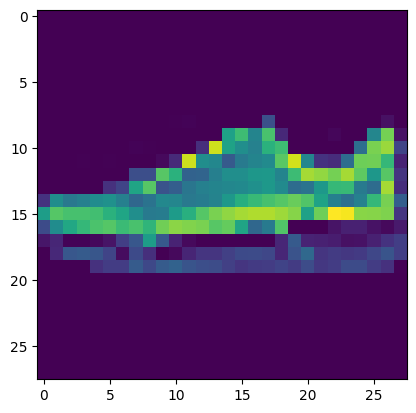

In [15]:
import matplotlib.pyplot as plt
X = mnist_test_totensor[9][0]
# 转化为图像, 可以被 plt.imshow() 显示图像
X = transforms.ToPILImage()(X)
plt.imshow(X)

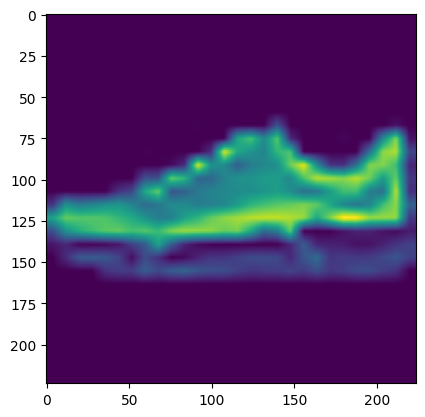

In [19]:
import matplotlib.pyplot as plt
X = mnist_test_totensor[9][0]
# 转化为图像, 可以被 plt.imshow() 显示图像
trans = [
    transforms.Resize((224, 224)),
    transforms.ToPILImage(),
]
# 转化列表为torchvision.transforms.transforms.Compose对象, 这样就能写 transform=trans
trans = transforms.Compose(trans)
X = trans(X)
plt.imshow(X)

# DataLoader

## 加载

In [25]:
batch_size = 16
# shuffle, 打乱
# num_workers, 使用4个进程来读取数据
train_iter = data.DataLoader(
    mnist_train_totensor, batch_size, shuffle=True, num_workers=4)
test_iter = data.DataLoader(
    mnist_test_totensor, batch_size, shuffle=True, num_workers=4)

打乱不打乱, 是指取出的此批数据是乱序的.

打乱 shuffle=True, 每次迭代都不一样

不打乱 shuffle=False, 每次迭代都一样

In [31]:
def hhh(test_iter):
    for X, y in test_iter:
        break

    for X2, y2 in test_iter:
        break

    X3, y3 = next(iter(test_iter))

    print((X == X3).min(), (y == y3).min(), (X == X2).min(), (y == y2).min())
    
    
# 打乱
test_iter = data.DataLoader(
    mnist_test_totensor, batch_size, shuffle=True, num_workers=4)
hhh(test_iter)

# 不打乱
test_iter = data.DataLoader(
    mnist_test_totensor, batch_size, shuffle=False, num_workers=4)
hhh(test_iter)

tensor(False) tensor(False) tensor(False) tensor(False)
tensor(True) tensor(True) tensor(True) tensor(True)


## 操作

### 数据集大小

In [7]:
print(len(mnist_test))

# 可以通过 test_iter.dataset，获取到原来传入的 DataSet。
print(len(test_iter.dataset))

# batch_size=16, 10000/16=625.
print(len(test_iter))

10000
10000
625


### 取出一批来

In [32]:
X, y = next(iter(test_iter))
X, y

(tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]]],
 
 
         [[[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]]],
 
 
         [[[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]]],
 
 
         ...,
 
 
         [[[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ..

### 遍历

train_iter 和 test_iter 都能获取到 X 特征值和 y 标签

In [15]:
for X, y in test_iter:
    # X是特征值，y是标签
    # X 是 batch_size 个行的1通道28*28图像, y是 batch_size 个标签
    print(X.shape, y.shape)
    break

torch.Size([16, 1, 28, 28]) torch.Size([16])


In [16]:
# 必须是batch, (X, y)，不能是batch, X, y
for batch, (X, y) in enumerate(test_iter):
    # batch是第几批batch，X是特征值，y是标签
    print(batch, X.shape, y.shape)
    break

0 torch.Size([16, 1, 28, 28]) torch.Size([16])
